In [146]:
import pandas as pd
import numpy as np

In [147]:
df = pd.read_csv("F:\Datasets and ML\datasets\customer.csv")

In [148]:
df.sample(5)

,age,gender,review,education,purchased
12,51,Male,Poor,School,No
36,34,Female,Good,UG,Yes
31,22,Female,Poor,School,Yes
15,75,Male,Poor,UG,No
6,18,Male,Good,School,No


In [149]:
df = df.iloc[:,2:]

In [150]:
from sklearn.model_selection import train_test_split

In [151]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(['purchased'], axis=1),df['purchased'], test_size=0.2, random_state=11)


In [152]:
df.value_counts()

review   education  purchased
Good     School     No           6
         UG         Yes          5
Poor     PG         No           5
Average  UG         No           4
Good     PG         Yes          4
Poor     PG         Yes          4
Average  School     No           3
Poor     School     Yes          3
         UG         No           2
         School     No           2
         UG         Yes          2
Average  PG         Yes          2
Good     PG         No           2
Average  UG         Yes          2
         School     Yes          2
Good     UG         No           1
Average  PG         No           1
Name: count, dtype: int64

In [153]:
X_train.head()

,review,education
14,Poor,PG
42,Good,PG
5,Average,School
35,Poor,School
30,Average,UG


In [154]:
from sklearn.preprocessing import OrdinalEncoder

In [155]:
oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

In [156]:
oe.fit(X_train)

,categories,"[['Poor', 'Average', ...], ['School', 'UG', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [157]:
X_train = oe.transform(X_train)

In [158]:
X_test = oe.transform(X_test)

In [159]:
X_train

array([[0., 2.],
       [2., 2.],
       [1., 0.],
       [0., 0.],
       [1., 1.],
       [2., 1.],
       [0., 2.],
       [0., 2.],
       [2., 1.],
       [1., 2.],
       [0., 1.],
       [1., 0.],
       [2., 0.],
       [2., 2.],
       [2., 1.],
       [2., 0.],
       [2., 2.],
       [0., 0.],
       [1., 1.],
       [2., 0.],
       [2., 2.],
       [0., 2.],
       [1., 0.],
       [2., 1.],
       [0., 1.],
       [1., 1.],
       [1., 0.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [1., 2.],
       [2., 0.],
       [0., 0.],
       [2., 2.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 2.],
       [0., 1.],
       [2., 0.]])

In [160]:
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

In [161]:
from sklearn.preprocessing import LabelEncoder

In [162]:
le = LabelEncoder() #it is only for target variable not for input x

In [163]:
le.fit(y_train)

LabelEncoder()

In [164]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [165]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)
y_train

array([1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0])

In [169]:
pd.DataFrame(X_train).head()
df_train = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_test)], axis=0)

# 2. Get the value counts of the 0th column and sort the index (0.0, 1.0, 2.0)
column_0_counts = df_train[0].value_counts().sort_index()


In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\DELL\AppData\Local\Temp\ipykernel_11344\2175349900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['review'], ax=ax[0], palette='Set1', edgecolor='black')


<BarContainer object of 3 artists>

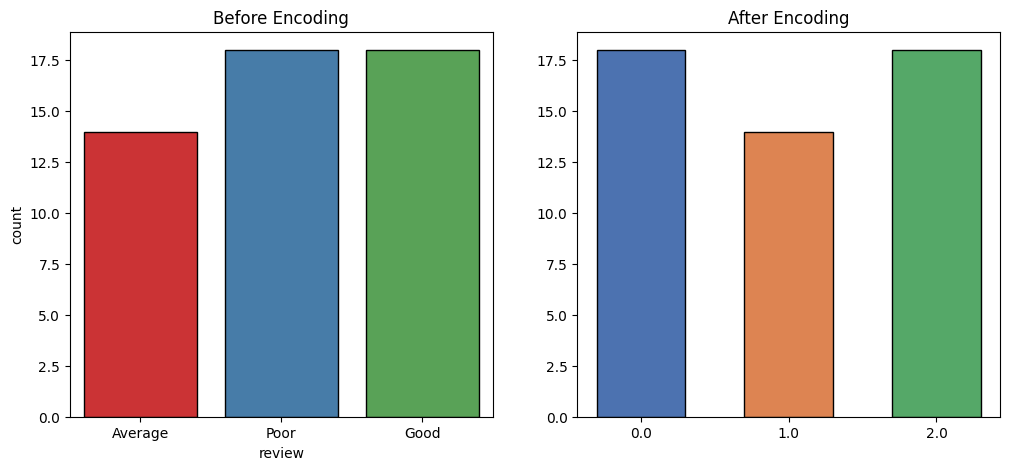

In [170]:
fig,ax = plt.subplots(ncols=2,figsize = (12,5))
ax[0].set_title('Before Encoding')
sns.countplot(x=df['review'], ax=ax[0], palette='Set1', edgecolor='black')
ax[1].set_title('After Encoding')
# 3. Plot the bar chart

ax[1].bar(column_0_counts.index.astype(str), column_0_counts.values, color = sns.color_palette('deep', len(df.columns)), edgecolor='black', width=0.6)


In [171]:
df['review'].value_counts()

review
Poor       18
Good       18
Average    14
Name: count, dtype: int64